In [166]:
from typing import TypedDict, Annotated, final

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command

load_dotenv()

True

In [167]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    approved: bool

In [168]:
llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.4, reasoning_format="hidden")

search_tool = TavilySearch(
    max_results=3,
    topic="general",
    include_images=False,
    search_depth="advanced"
)
tool_list = [search_tool]
llm_with_tool = llm.bind_tools(tool_list)

In [169]:
def chat_node(state: ChatState) -> ChatState:
    # print(list(state["messages"]))
    response_llm = llm_with_tool.invoke(input=state["messages"])
    return {"messages": [response_llm]}

In [170]:
tools_node = ToolNode(tool_list)

In [171]:
def should_continue(state: ChatState) -> str:
    """Determine if we should continue or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]

    # If no tools were called, we're done
    if not last_message.tool_calls:
        return END
    else:
        return "ask_human"

In [172]:
def ask_human(state: ChatState) -> ChatState:
    decision = interrupt({
        "type": "tool_decision",
        "tool_call": state["messages"][-1].tool_calls[0],
        "user_message": "LLM is trying to access the tool, do you want to allow it yes or no?"
    })
    return {"approved": decision["allow"] == "yes"}


def after_human(state: ChatState) -> str:
    # Honor the human's decision: run the tool only if approved.
    return "tools" if state["approved"] else END

In [173]:
checkpointer = InMemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tools_node)
graph.add_node("ask_human", ask_human)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_continue, {"ask_human": "ask_human", END: END})
graph.add_conditional_edges("ask_human", after_human, {"tools": "tools", END: END})
graph.add_edge("tools", "chat_node")

workflow = graph.compile(checkpointer=checkpointer)

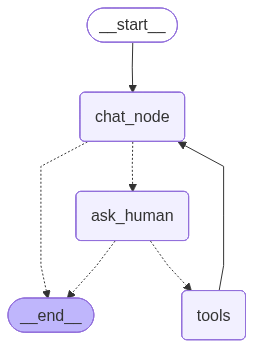

In [174]:
workflow

In [175]:
thread_id = "mychat-ui-4"
config = {"configurable": {"thread_id": thread_id}}

# while True:
user_message = input("Human: ")
initial_state = {"messages": [HumanMessage(content=user_message)]}

print(f"Human: {user_message}")
# if user_message.lower().strip() in ["bye", "exit", "quit"]:
#     break

response = workflow.invoke(input=initial_state, config=config)
print(f"AI: {workflow.get_state(config)} \n")

Human: Check the date today on internet
AI: StateSnapshot(values={'messages': [HumanMessage(content='Check the date today on internet', additional_kwargs={}, response_metadata={}, id='cd9a3720-96ba-4bd2-b7b3-52976cff640b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8m0ycq5ys', 'function': {'arguments': '{"query":"current date","search_depth":"fast","time_range":"day"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 586, 'prompt_tokens': 1708, 'total_tokens': 2294, 'completion_time': 1.3225453329999999, 'completion_tokens_details': {'reasoning_tokens': 546}, 'prompt_time': 0.103268861, 'prompt_tokens_details': None, 'queue_time': 0.264964031, 'total_time': 1.425814194}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef6e4-ff6c-7d33-a06e-ec88ad26336b-0', tool_calls=[

In [176]:
user_input = input("Do you want to allow the tool access. yes or no ?" )

In [177]:
response1 =  workflow.invoke(Command(resume={"allow": user_input}), config=config)
final = "Human rejected the tool use" if not response1['messages'][-1].content else response1['messages'][-1].content
print(f"AI: {final} \n")


AI: The current date, according to the search results, is **Wednesday, June 24, 2026** (based on the source from calendardate.com, which specifies the date in multiple formats, including ISO-8601: `2026-06-24`). 

A secondary source (isotropic.org) shows **Tuesday, June 23, 2026**, which may reflect a different time zone or a discrepancy in the data. For most purposes, **June 24, 2026** is the date provided by the most detailed and comprehensive result. 

